<a href="https://colab.research.google.com/github/ronak8180/Ronak-Waghmare/blob/main/Bitcoin_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
senti = pd.read_csv("fear_greed_index.csv")
df = pd.read_csv("historical_data.csv")

In [ ]:
senti.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,01/02/18
1,1517549400,15,Extreme Fear,02/02/18
2,1517635800,40,Fear,03/02/18
3,1517722200,24,Extreme Fear,04/02/18
4,1517808600,11,Extreme Fear,05/02/18


In [ ]:
df.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02/12/24 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02/12/24 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02/12/24 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02/12/24 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02/12/24 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
senti.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
senti.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
# Historical trades
df['Timestamp'] = pd.to_datetime(df['Timestamp IST'], format='%d/%m/%y %H:%M', errors='coerce')
df['Date'] = df['Timestamp'].dt.date   # <-- this creates a clean date column



In [ ]:
senti['Date'] = pd.to_datetime(senti['date'], format='%d/%m/%y', errors='coerce').dt.date


In [ ]:

senti['classification'] = senti['classification'].astype('category')

In [ ]:
# Filter for BTC trades only
df_btc = df[df['Coin'] == 'BTC']


In [ ]:
df_btc.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date
3001,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.08585,7061.59,BUY,17/03/25 4:48,0.00000,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,2.372694,7.470000e+14,2025-03-17 04:48:00,2025-03-17
3002,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.12157,9999.74,BUY,17/03/25 4:48,0.08585,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,3.359912,7.020000e+13,2025-03-17 04:48:00,2025-03-17
3003,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.00937,770.73,BUY,17/03/25 4:48,0.20742,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,0.258964,1.970000e+14,2025-03-17 04:48:00,2025-03-17
3004,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.12372,10176.59,BUY,17/03/25 4:48,0.21679,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,3.419333,1.090000e+15,2025-03-17 04:48:00,2025-03-17
3005,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,2.64792,217804.66,BUY,17/03/25 4:48,0.34051,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,73.182364,3.470000e+13,2025-03-17 04:48:00,2025-03-17


In [ ]:
# Merge with sentiment
merged_df = pd.merge(
    df_btc,
    senti[['Date', 'classification']],
    on='Date',
    how='left'
)

In [ ]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.08585,7061.59,BUY,17/03/25 4:48,0.00000,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,2.372694,7.470000e+14,2025-03-17 04:48:00,2025-03-17,Fear
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.12157,9999.74,BUY,17/03/25 4:48,0.08585,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,3.359912,7.020000e+13,2025-03-17 04:48:00,2025-03-17,Fear
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.00937,770.73,BUY,17/03/25 4:48,0.20742,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,0.258964,1.970000e+14,2025-03-17 04:48:00,2025-03-17,Fear
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,0.12372,10176.59,BUY,17/03/25 4:48,0.21679,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,3.419333,1.090000e+15,2025-03-17 04:48:00,2025-03-17,Fear
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,2.64792,217804.66,BUY,17/03/25 4:48,0.34051,Open Long,0.0,0x7757437fee55ca858e3f041fb178b10201d700ac1b50...,80242832045,True,73.182364,3.470000e+13,2025-03-17 04:48:00,2025-03-17,Fear


In [ ]:
# Drop irrelevant cols (ignore missing)
merged_df = merged_df.drop(columns=['Transaction Hash','Order ID','Trade ID','Account'], errors='ignore')


In [ ]:
merged_df.head()

,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Crossed,Fee,Timestamp,Date,classification
0,BTC,82255.0,0.08585,7061.59,BUY,17/03/25 4:48,0.00000,Open Long,0.0,True,2.372694,2025-03-17 04:48:00,2025-03-17,Fear
1,BTC,82255.0,0.12157,9999.74,BUY,17/03/25 4:48,0.08585,Open Long,0.0,True,3.359912,2025-03-17 04:48:00,2025-03-17,Fear
2,BTC,82255.0,0.00937,770.73,BUY,17/03/25 4:48,0.20742,Open Long,0.0,True,0.258964,2025-03-17 04:48:00,2025-03-17,Fear
3,BTC,82255.0,0.12372,10176.59,BUY,17/03/25 4:48,0.21679,Open Long,0.0,True,3.419333,2025-03-17 04:48:00,2025-03-17,Fear
4,BTC,82255.0,2.64792,217804.66,BUY,17/03/25 4:48,0.34051,Open Long,0.0,True,73.182364,2025-03-17 04:48:00,2025-03-17,Fear


In [ ]:
# Encode Side
merged_df['Side'] = merged_df['Side'].map({'BUY': 1, 'SELL': 0})



In [ ]:
# Encode Direction
Direction_map = {
    'Buy': 1,
    'Open Long': 1,
    'Long > Short': 1,
    'Short > Long': 1,
    'Sell': -1,
    'Open Short': -1,
    'Close Long': 0,
    'Close Short': 0,
    'Spot Dust Conversion': 0,
    'Auto-Deleveraging': 0
}
merged_df['Direction_num'] = merged_df['Direction'].map(Direction_map)


In [ ]:

# Profit flag
merged_df['Profit_flag'] = (merged_df['Closed PnL'] > 0).astype(int)


In [ ]:
merged_df = merged_df.drop(columns=['Direction','Timestamp IST'], errors='ignore')

In [ ]:
# Replace df with your DataFrame name (example: summary)
df.to_csv("merged_df.csv", index=False)
from google.colab import files

df.to_csv("merged_df.csv", index=False)
files.download("merged_df.csv")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

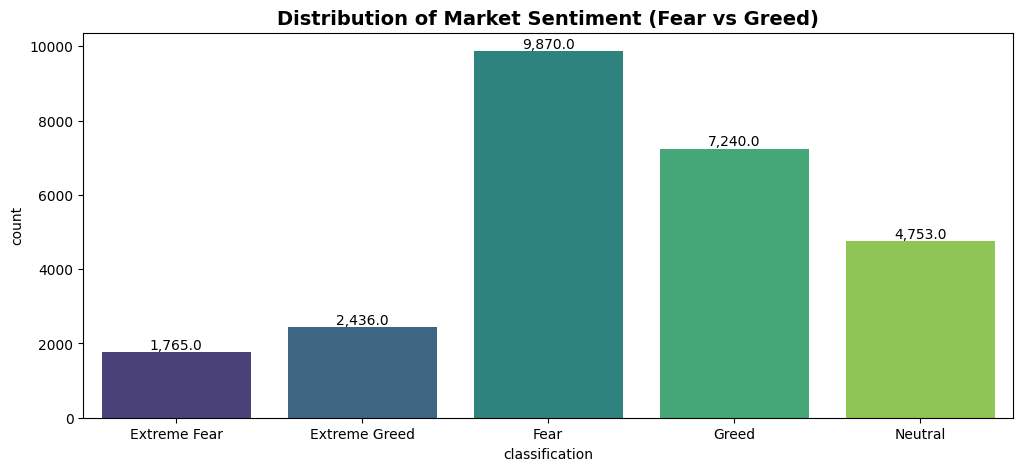

In [ ]:
# -----------------------------
# 1. Sentiment distribution
# -----------------------------
plt.figure(figsize=(12,5))
ax = sns.countplot(
    data=merged_df,
    x="classification",
    hue="classification",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Market Sentiment (Fear vs Greed)", fontsize=14, weight="bold")
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()


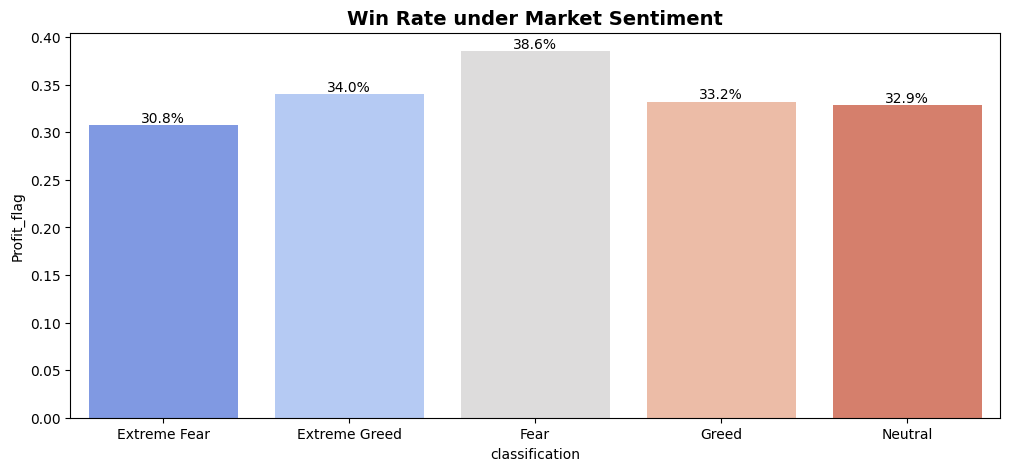

In [ ]:
# -----------------------------
# 2. Win rate by sentiment
# -----------------------------
profit_rate = (
    merged_df.groupby('classification', observed=True)['Profit_flag']
    .mean()
    .reset_index()
)
plt.figure(figsize=(12,5))
ax = sns.barplot(
    data=profit_rate,
    x="classification",
    y="Profit_flag",
    hue="classification",
    palette="coolwarm",
    legend=False
)

plt.title("Win Rate under Market Sentiment", fontsize=14, weight="bold")
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()


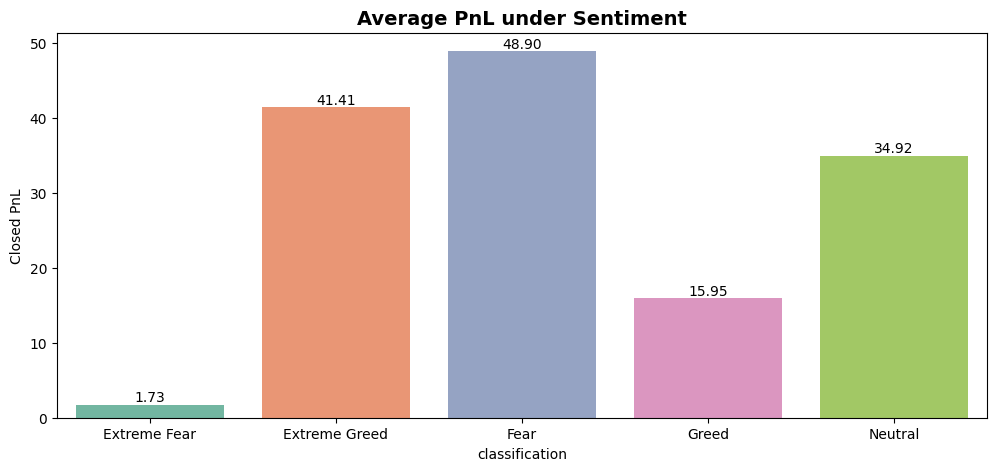

In [ ]:
# -----------------------------
# 3. Average PnL by sentiment
# -----------------------------
avg_pnl = (
    merged_df.groupby('classification', observed=True)['Closed PnL']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))
ax = sns.barplot(
    data=avg_pnl,
    x="classification",
    y="Closed PnL",
    hue="classification",      # fix seaborn future warning
    palette="Set2",
    legend=False
)
plt.title("Average PnL under Sentiment", fontsize=14, weight="bold")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()


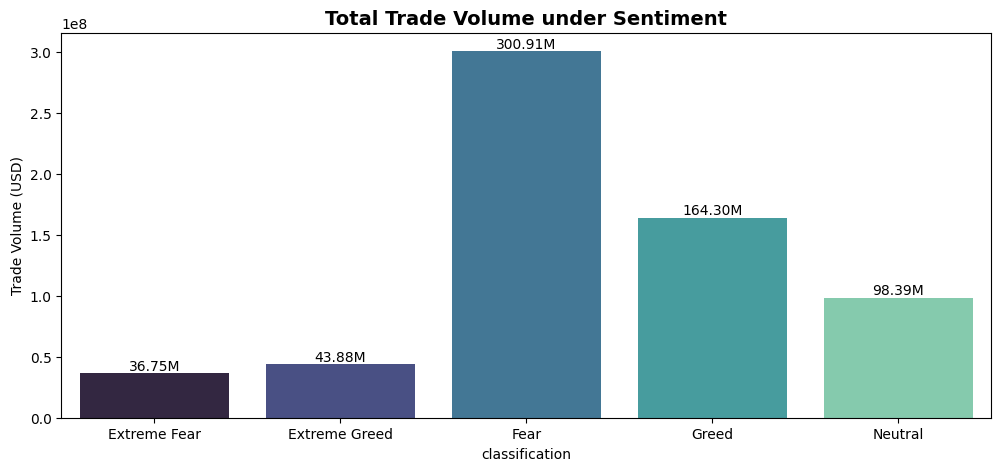

In [ ]:
# -----------------------------
# 4. Total Trade Volume by sentiment
# -----------------------------
trade_volume = (
    merged_df.groupby('classification', observed=True)['Size USD']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))
ax = sns.barplot(
    data=trade_volume,
    x="classification",
    y="Size USD",
    hue="classification",  # fix seaborn future warning
    palette="mako",
    legend=False
)
plt.title("Total Trade Volume under Sentiment", fontsize=14, weight="bold")
plt.ylabel("Trade Volume (USD)")

for p in ax.patches:
    ax.annotate(f'{p.get_height()/1e6:.2f}M',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()


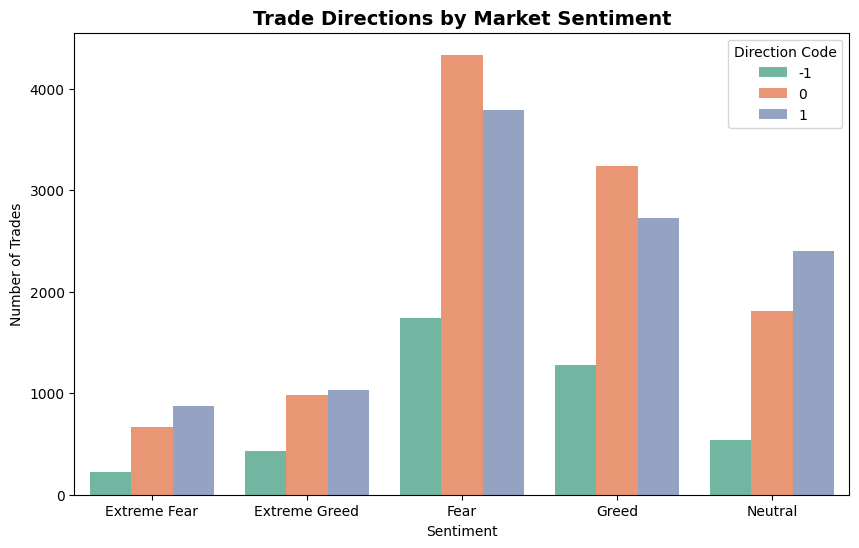

In [ ]:
# -----------------------------
# 5. Trade Direction
# -----------------------------
plt.figure(figsize=(10,6))
ax = sns.countplot(data=merged_df, x="classification", hue="Direction_num", palette="Set2")
plt.title("Trade Directions by Market Sentiment", fontsize=14, weight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.legend(title="Direction Code")
plt.show()

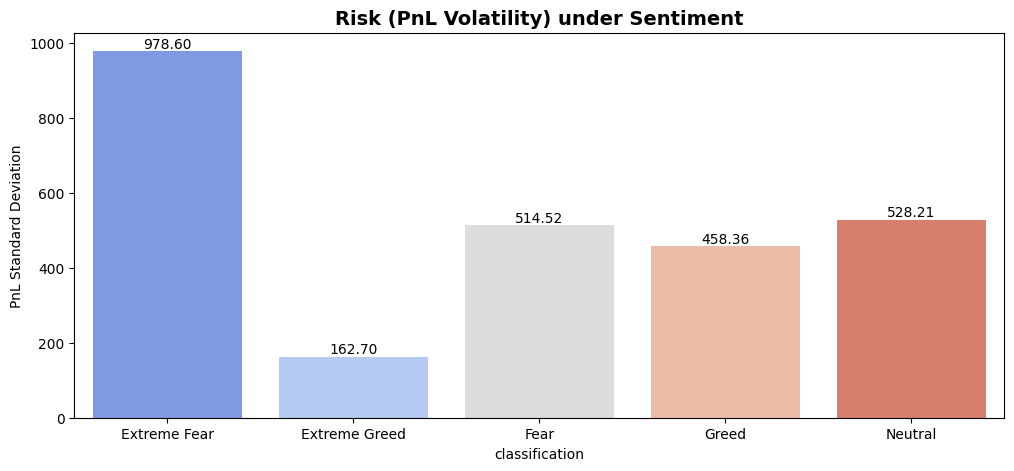

In [ ]:
# -----------------------------
# 6. Risk (PnL Volatility) by sentiment
# -----------------------------
risk_analysis = (
    merged_df.groupby("classification", observed=True)["Closed PnL"]
    .std()
    .reset_index()
)

plt.figure(figsize=(12,5))
ax = sns.barplot(
    data=risk_analysis,
    x="classification",
    y="Closed PnL",
    hue="classification",  # fix seaborn warning
    palette="coolwarm",
    legend=False
)
plt.title("Risk (PnL Volatility) under Sentiment", fontsize=14, weight="bold")
plt.ylabel("PnL Standard Deviation")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()
